In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from sklearn.decomposition import PCA

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5307.20it/s]

Ready!


In [2]:
import urllib.request


url = "https://www.gutenberg.org/files/2701/2701-0.txt"
with urllib.request.urlopen(url) as f:
    book_text = f.read().decode("utf-8")

sentences = [s.strip() for s in book_text.split(".") 
             if len(s.strip()) > 30][:100]


all_layer_embeddings = {i: [] for i in range(13)}

for sentence in sentences:
    inputs = tokenizer(sentence, 
                      return_tensors="pt",
                      max_length=32,
                      truncation=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    for layer_idx, hidden in enumerate(outputs.hidden_states):
        
        emb = hidden[0].mean(dim=0).numpy()
        all_layer_embeddings[layer_idx].append(emb)

print(f"Collected embeddings for {len(sentences)} sentences!")
print(f"Each layer has {len(all_layer_embeddings[0])} embeddings")

Collected embeddings for 100 sentences!
Each layer has 100 embeddings


In [3]:
from sklearn.decomposition import PCA

effective_dims = []

for layer_idx in range(13):
    X = np.array(all_layer_embeddings[layer_idx])
    
    
    pca = PCA()
    pca.fit(X)
    
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components_95 = np.argmax(cumvar >= 0.95) + 1
    
    effective_dims.append(n_components_95)
    
    label = "Emb" if layer_idx == 0 else f"L{layer_idx}"
    print(f"{label:<6}: {n_components_95:3d} dimensions "
          f"explain 95% variance")

print(f"\nTotal dimensions: 768")
print(f"Min effective: {min(effective_dims)}")
print(f"Max effective: {max(effective_dims)}")

Emb   :  61 dimensions explain 95% variance
L1    :  64 dimensions explain 95% variance
L2    :  44 dimensions explain 95% variance
L3    :   1 dimensions explain 95% variance
L4    :   2 dimensions explain 95% variance
L5    :   3 dimensions explain 95% variance
L6    :   6 dimensions explain 95% variance
L7    :  12 dimensions explain 95% variance
L8    :  20 dimensions explain 95% variance
L9    :  28 dimensions explain 95% variance
L10   :  37 dimensions explain 95% variance
L11   :  44 dimensions explain 95% variance
L12   :   4 dimensions explain 95% variance

Total dimensions: 768
Min effective: 1
Max effective: 64


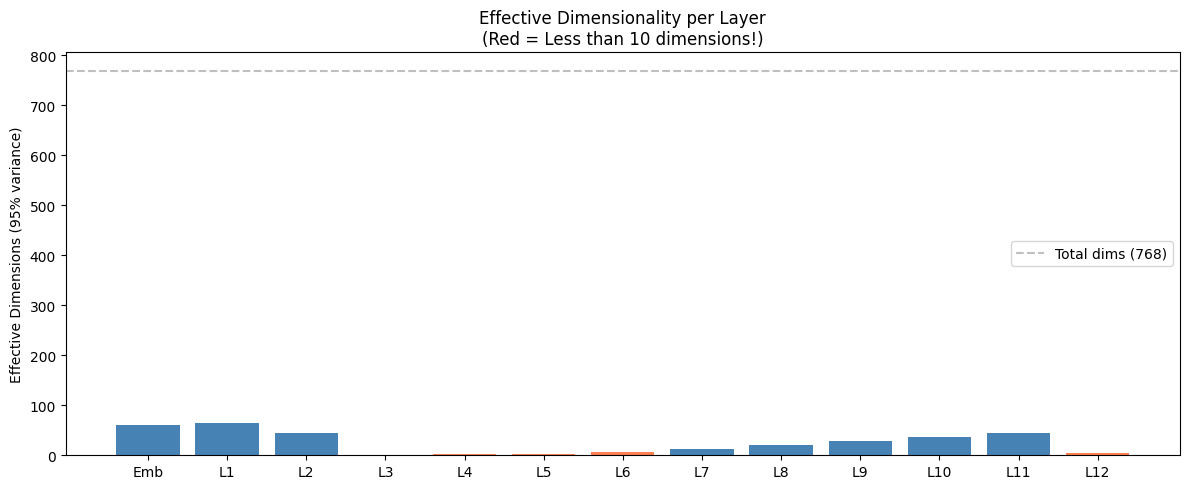

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

x       = range(13)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]
colors  = ["coral" if d < 10 else "steelblue" 
           for d in effective_dims]

ax.bar(x, effective_dims, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_ylabel("Effective Dimensions (95% variance)")
ax.set_title("Effective Dimensionality per Layer\n"
             "(Red = Less than 10 dimensions!)")
ax.axhline(y=768, color="gray", linestyle="--", 
           alpha=0.5, label="Total dims (768)")
ax.legend()

plt.tight_layout()
plt.show()


* In GPT-2’s 768 dimensions, only about **1–64 dimensions are actually useful**.
* **Layer 3** is the most compressed — effectively using **just 1 dimension**.
* This aligns with **Project 25** — where everything looked similar in Layer 3.
* There is **high redundancy** — suggesting that large language models can be **over-engineered**.
